# Entrenamiento — Clasificador de fallas en módulos solares (Infrared Solar Modules)

Descarga el dataset de Kaggle (12 clases), lo combina con las imágenes `MPPT` de `RECURSOS` como ejemplos extra de `No-Anomaly`, entrena un ResNet18 por transfer learning con Data Augmentation y Early Stopping, calcula métricas (Accuracy, Precision, Recall, F1) y matriz de confusión, y guarda el modelo en `modeloEntrenado/infrared_solar_modules_model.pth`.

In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
sys.path.append(str(PROJECT_ROOT / "src"))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image

from config import (
    BATCH_SIZE, CLASS_WEIGHT_POWER, CLASSES, MODEL_DIR, MODEL_PATH, NUM_WORKERS,
    RESULTS_DIR, SEED, SPLIT_INDEX_CSV,
)
from dataset import InfraredSolarModulesDataset, build_transforms
from model import build_model
from evaluate import evaluate_model
from engine import EarlyStopping, run_epoch

torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

Dispositivo: cpu


## 1. Descargar el dataset de Kaggle

Requiere credenciales de Kaggle ya configuradas (`~/.kaggle/access_token` o variable `KAGGLE_API_TOKEN`).

In [2]:
from download_dataset import download

kaggle_root = download()
kaggle_root

Ya existe C:\Users\sofia\Downloads\Infrared_solar_modules\data\InfraredSolarModules, se omite la descarga.


WindowsPath('C:/Users/sofia/Downloads/Infrared_solar_modules/data/InfraredSolarModules')

## 2. Construir el índice combinado (Kaggle + MPPT de RECURSOS)

In [3]:
from prepare_dataset import build_index

df = build_index()
df.head()

Total de imágenes indexadas: 20027
label
No-Anomaly        10027
Cell               1877
Vegetation         1639
Diode              1499
Cell-Multi         1288
Shadowing          1056
Cracking            940
Offline-Module      827
Hot-Spot            249
Hot-Spot-Multi      246
Soiling             204
Diode-Multi         175
dtype: int64

Índice guardado en C:\Users\sofia\Downloads\Infrared_solar_modules\data\split_index.csv
split
test      3005
train    14018
val       3004
dtype: int64


,filepath,label,source,needs_crop,split
0,C:\Users\sofia\Downloads\Infrared_solar_module...,No-Anomaly,kaggle,False,train
1,C:\Users\sofia\Downloads\Infrared_solar_module...,No-Anomaly,kaggle,False,train
2,C:\Users\sofia\Downloads\Infrared_solar_module...,No-Anomaly,kaggle,False,train
3,C:\Users\sofia\Downloads\Infrared_solar_module...,Cell,kaggle,False,train
4,C:\Users\sofia\Downloads\Infrared_solar_module...,No-Anomaly,kaggle,False,train


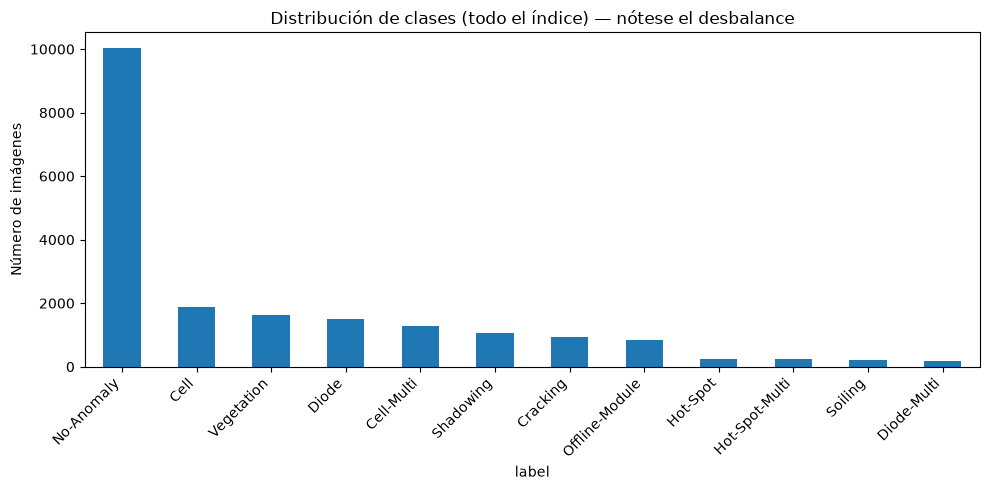

split
test      3005
train    14018
val       3004
dtype: int64

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
df["label"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Distribución de clases (todo el índice) — nótese el desbalance")
ax.set_ylabel("Número de imágenes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

df.groupby("split").size()

## 3. Vista previa de imágenes por clase

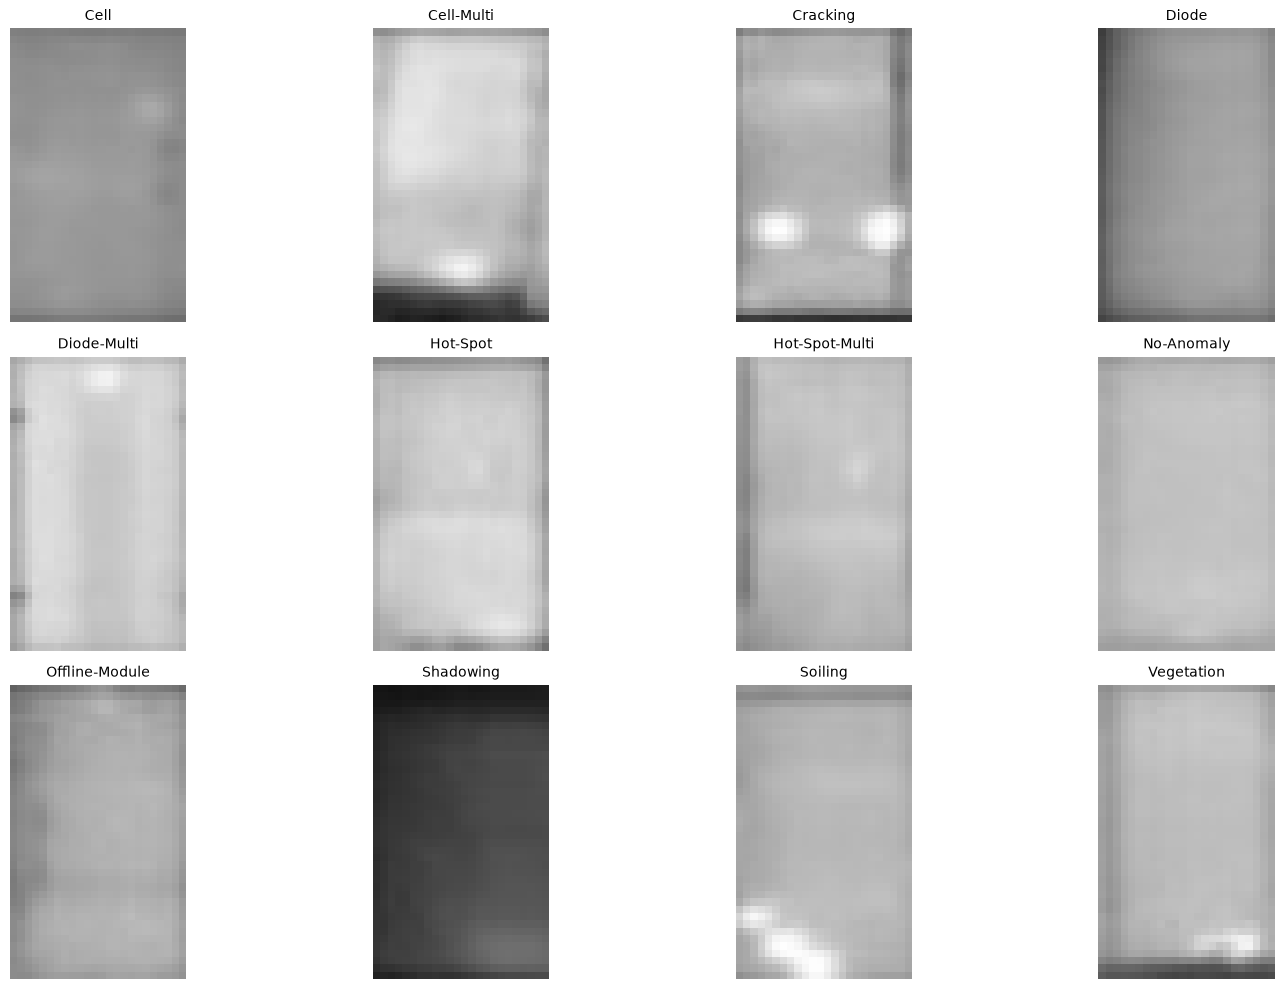

In [5]:
sample_rows = df.groupby("label").first().reset_index()
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, (_, row) in zip(axes.flat, sample_rows.iterrows()):
    img = cv2.cvtColor(cv2.imread(row["filepath"]), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(row["label"], fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Datasets y DataLoaders (con Data Augmentation)

In [6]:
train_ds = InfraredSolarModulesDataset(SPLIT_INDEX_CSV, "train", build_transforms(train=True))
val_ds = InfraredSolarModulesDataset(SPLIT_INDEX_CSV, "val", build_transforms(train=False))
test_ds = InfraredSolarModulesDataset(SPLIT_INDEX_CSV, "test", build_transforms(train=False))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

train=14018  val=3004  test=3005


## 5. Modelo (ResNet18 preentrenado, transfer learning) + pesos de clase

**Iteración 2, basada en resultados reales de la primera corrida** (accuracy=0.652, f1_macro=0.537, ver `resultados/metricas.json` y la matriz de confusión de esa corrida). Diagnóstico concreto:

- `class_weight="balanced"` sobrecorrigió: `No-Anomaly` tuvo precisión 0.95 pero recall solo 0.665 — el modelo empujaba demasiadas imágenes de paneles sanos hacia clases de falla (`Offline-Module` precisión 0.29, `Hot-Spot` 0.28, `Soiling` 0.24: la mayoría de sus predicciones eran en realidad paneles sanos mal clasificados).
- `Cell` / `Cell-Multi` fallaban en recall y precisión a la vez (0.36-0.43), confundidas difusamente con `Vegetation` y `Cracking` — señal de falta de capacidad del modelo (con `freeze_backbone=True` solo se entrenaba `layer4`), no de desbalance.

Cambios aplicados en `src/model.py` y acá:
1. **Pesos de clase suavizados** (`peso ** CLASS_WEIGHT_POWER`, con `CLASS_WEIGHT_POWER=0.5` en `config.py`) — mantiene la compensación por desbalance sin empujar tan agresivo.
2. **`layer3` + `layer4` descongelados** (antes solo `layer4`) y **Dropout(0.3)** antes de la capa final — más capacidad para separar las clases visualmente parecidas, con regularización para no sobreajustar con más parámetros entrenables.

In [7]:
model = build_model(freeze_backbone=True).to(device)

class_to_idx = {c: i for i, c in enumerate(CLASSES)}
train_labels = train_ds.df["label"].map(class_to_idx).to_numpy()
class_weights_balanced = compute_class_weight(
    class_weight="balanced", classes=np.arange(len(CLASSES)), y=train_labels
)
class_weights_arr = class_weights_balanced ** CLASS_WEIGHT_POWER
class_weights = torch.tensor(class_weights_arr, dtype=torch.float32, device=device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"Parámetros entrenables: {n_trainable:,} / {n_total:,}")

Parámetros entrenables: 10,499,596 / 11,182,668


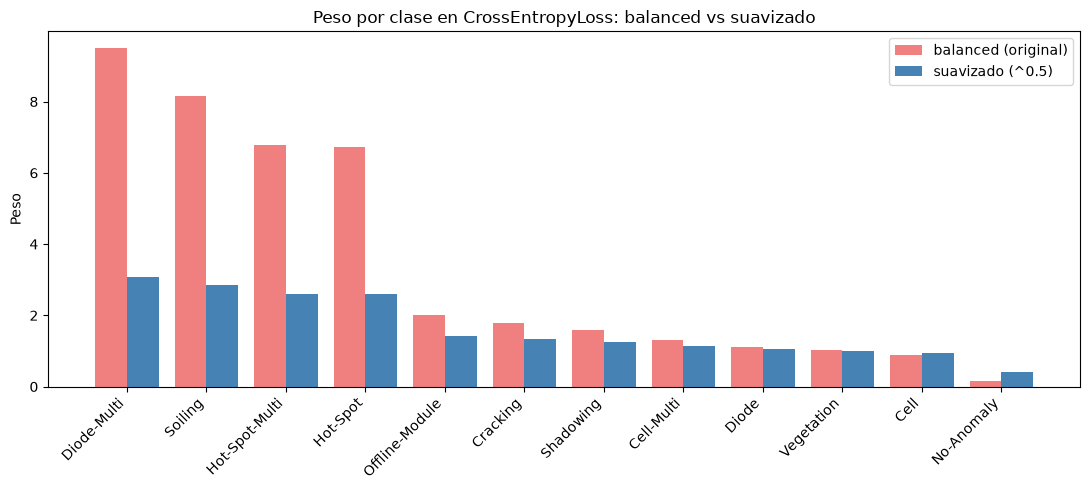

,clase,n_imagenes_train,peso_balanced,peso_suavizado
7,Diode-Multi,123,9.497290,3.081767
10,Soiling,143,8.168998,2.858146
5,Hot-Spot-Multi,172,6.791667,2.606083
4,Hot-Spot,174,6.713602,2.591062
8,Offline-Module,579,2.017559,1.420408
3,Cracking,658,1.775329,1.332415
9,Shadowing,739,1.580740,1.257275
2,Cell-Multi,902,1.295085,1.138018
6,Diode,1049,1.113600,1.055273
11,Vegetation,1147,1.018454,1.009185


In [8]:
weights_df = pd.DataFrame({
    "clase": CLASSES,
    "n_imagenes_train": [int((train_labels == i).sum()) for i in range(len(CLASSES))],
    "peso_balanced": class_weights_balanced,
    "peso_suavizado": class_weights_arr,
}).sort_values("peso_suavizado", ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(weights_df))
ax.bar(x - 0.2, weights_df["peso_balanced"], width=0.4, label="balanced (original)", color="lightcoral")
ax.bar(x + 0.2, weights_df["peso_suavizado"], width=0.4, label=f"suavizado (^{CLASS_WEIGHT_POWER})", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(weights_df["clase"], rotation=45, ha="right")
ax.set_title("Peso por clase en CrossEntropyLoss: balanced vs suavizado")
ax.set_ylabel("Peso")
ax.legend()
plt.tight_layout()
plt.show()

weights_df

### Si esta iteración todavía no alcanza, próximas palancas (en orden de impacto esperado)

1. **`WeightedRandomSampler`** en `train_loader`, si tras suavizar los pesos las clases más raras (`Diode-Multi`, `Hot-Spot-Multi`) vuelven a perder recall (con la corrida anterior no era el caso: ya tenían buen recall, por eso no se aplicó todavía).
2. **Monitorear F1-macro para el early stopping** en vez de solo `val_loss`, si el modelo converge a un óptimo que favorece accuracy global sobre las clases minoritarias.
3. **Focal Loss** en vez de weighted cross-entropy, si `Cell`/`Cell-Multi`/`Vegetation` siguen confundidas entre sí después de descongelar `layer3`.

La corrida anterior (antes de este cambio) quedó guardada en `resultados/corrida1_baseline/` (`metricas.json` + matriz de confusión) para comparar contra los resultados nuevos de la sección 7.

## 6. Entrenamiento con Early Stopping

In [9]:
MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 7

early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE)
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer, device, train=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
        f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if early_stopping.step(val_loss, model):
        print(f"Early stopping en epoch {epoch} (sin mejora en {EARLY_STOPPING_PATIENCE} epochs).")
        break

model.load_state_dict(early_stopping.best_state)

Epoch 01 | train_loss=1.6870 train_acc=0.5474 | val_loss=1.3487 val_acc=0.6218
Epoch 02 | train_loss=1.2523 train_acc=0.6597 | val_loss=1.1793 val_acc=0.6961
Epoch 03 | train_loss=1.1162 train_acc=0.6982 | val_loss=1.1234 val_acc=0.6881
Epoch 04 | train_loss=1.0265 train_acc=0.7190 | val_loss=1.0568 val_acc=0.7097
Epoch 05 | train_loss=0.9755 train_acc=0.7285 | val_loss=0.9730 val_acc=0.7307
Epoch 06 | train_loss=0.8852 train_acc=0.7502 | val_loss=0.9898 val_acc=0.7447
Epoch 07 | train_loss=0.8549 train_acc=0.7630 | val_loss=0.8965 val_acc=0.7693
Epoch 08 | train_loss=0.8023 train_acc=0.7697 | val_loss=0.9279 val_acc=0.7650
Epoch 09 | train_loss=0.7670 train_acc=0.7854 | val_loss=0.8957 val_acc=0.7730
Epoch 10 | train_loss=0.7461 train_acc=0.7872 | val_loss=0.8630 val_acc=0.7826
Epoch 11 | train_loss=0.7044 train_acc=0.7966 | val_loss=0.9152 val_acc=0.7670
Epoch 12 | train_loss=0.6747 train_acc=0.8061 | val_loss=0.8953 val_acc=0.7716
Epoch 13 | train_loss=0.6535 train_acc=0.8142 | val_

<All keys matched successfully>

In [ ]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
with open(RESULTS_DIR / "historial_entrenamiento.json", "w", encoding="utf-8") as f:
    json.dump(history, f, indent=2, ensure_ascii=False)
print(f"Historial de entrenamiento guardado en {RESULTS_DIR / 'historial_entrenamiento.json'}")

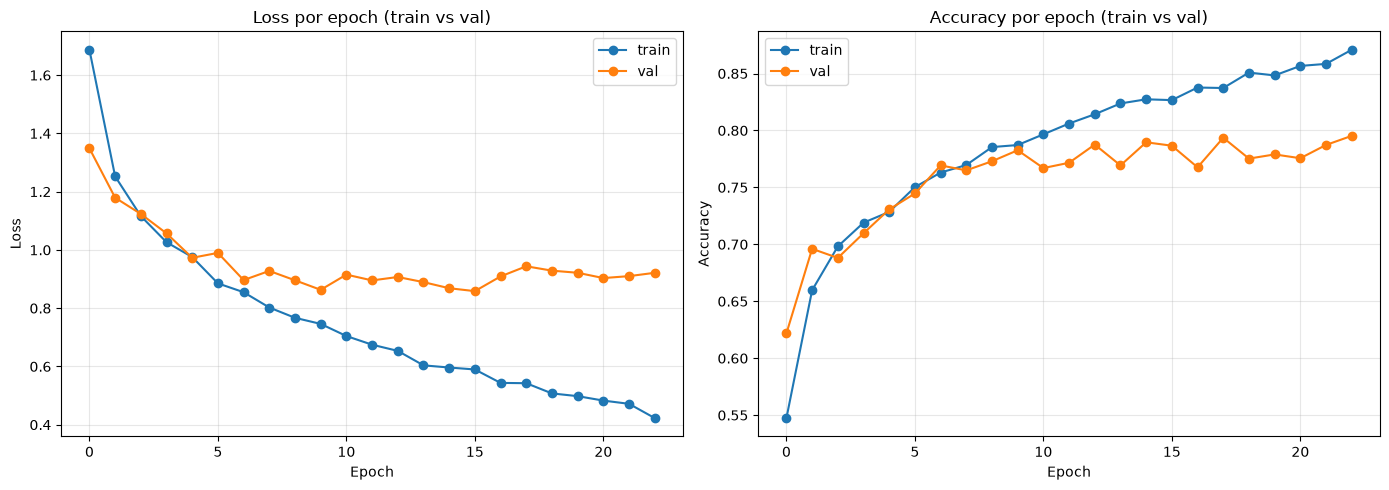

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="train", marker="o")
axes[0].plot(history["val_loss"], label="val", marker="o")
axes[0].set_title("Loss por epoch (train vs val)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(history["train_acc"], label="train", marker="o")
axes[1].plot(history["val_acc"], label="val", marker="o")
axes[1].set_title("Accuracy por epoch (train vs val)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Evaluación final (Accuracy, Precision, Recall, F1, por clase y matriz de confusión)

In [11]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
test_metrics = evaluate_model(
    model, test_loader, device, confusion_matrix_path=RESULTS_DIR / "matriz_confusion.png"
)

per_class_df = test_metrics.pop("per_class")
print({k: round(v, 4) for k, v in test_metrics.items()})

with open(RESULTS_DIR / "metricas.json", "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=2, ensure_ascii=False)

per_class_df.to_csv(RESULTS_DIR / "metricas_por_clase.csv")
per_class_df

{'accuracy': 0.791, 'precision_macro': 0.6466, 'recall_macro': 0.6881, 'f1_macro': 0.6616}


,precision,recall,f1-score,support
No-Anomaly,0.927744,0.904319,0.915882,1505
Cell,0.711111,0.567376,0.631164,282
Cell-Multi,0.495283,0.544041,0.518519,193
Cracking,0.729167,0.744681,0.736842,141
Hot-Spot,0.552632,0.567568,0.560000,37
Hot-Spot-Multi,0.362319,0.675676,0.471698,37
Diode,0.908714,0.973333,0.939914,225
Diode-Multi,0.888889,0.923077,0.905660,26
Offline-Module,0.537931,0.629032,0.579926,124
Shadowing,0.630058,0.685535,0.656627,159


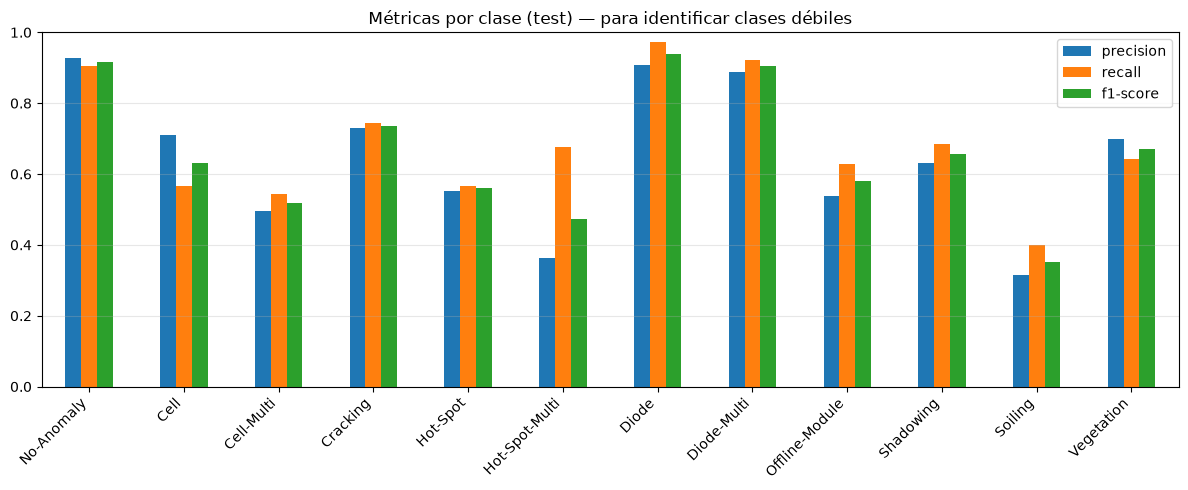

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
per_class_df.loc[CLASSES, ["precision", "recall", "f1-score"]].plot(kind="bar", ax=ax)
ax.set_title("Métricas por clase (test) — para identificar clases débiles")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3, axis="y")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

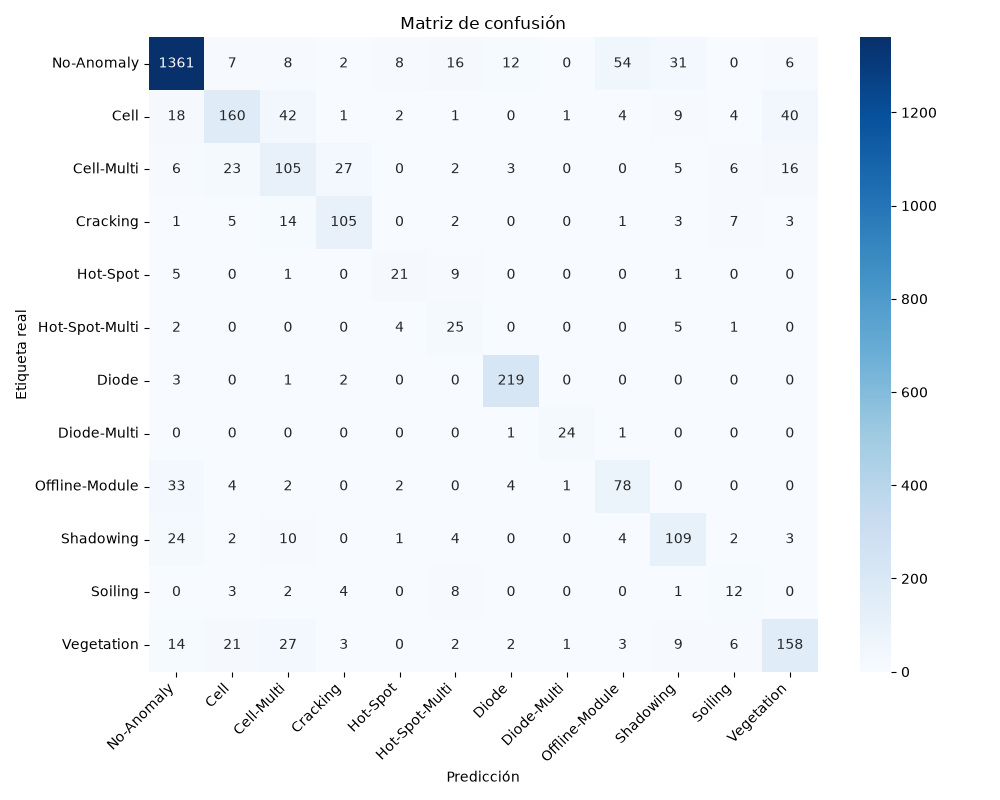

In [13]:
Image.open(RESULTS_DIR / "matriz_confusion.png")

## 8. Guardar el modelo entrenado

In [14]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "classes": CLASSES,
        "class_to_idx": class_to_idx,
    },
    MODEL_PATH,
)
print(f"Modelo guardado en {MODEL_PATH}")

Modelo guardado en C:\Users\sofia\Downloads\Infrared_solar_modules\modeloEntrenado\infrared_solar_modules_model.pth


### Exportar metadatos del entrenamiento (JSON)

Genera `modeloEntrenado/metadata_entrenamiento.json` con arquitectura, hiperparámetros, datos usados y métricas finales — para compartir o revisar los resultados sin tener que volver a entrenar.

In [ ]:
from export_metadata import export as export_metadata

export_metadata()